# Stagger vs Single Large Run: 2D Replica Exchange Comparison

Compares two strategies for covering a fine temperature grid in 2D RE:
- **Approach A (Stagger)**: Multiple 10x10 RE runs at staggered offsets (3 per dimension = 9 sub-runs), combined to fill a 30x30 fine grid.
- **Approach B (Single)**: One 30x30 RE run with all 900 replicas.

Both approaches use the same total number of MC steps across all replicas, ensuring a fair comparison. Multiple independent repeats provide error bars.

**Protein pair**: PF00004 x PF00041, overlap = 62 nt, frame 0.

In [3]:
# === Cell 1: Configuration ===

import numpy as np

# --- Data paths ---
DATA_DIR = "../bmDCA"
PF1 = "PF00004"
PF2 = "PF00041"

PARAMS_FILE_1 = f"{DATA_DIR}/{PF1}/{PF1}_params.dat"
PARAMS_FILE_2 = f"{DATA_DIR}/{PF2}/{PF2}_params.dat"
NAT_ENERGIES_FILE_1 = f"{DATA_DIR}/{PF1}/{PF1}_naturalenergies.txt"
NAT_ENERGIES_FILE_2 = f"{DATA_DIR}/{PF2}/{PF2}_naturalenergies.txt"

# --- Overlap ---
OVERLAP_LEN = 62

# --- Temperature grid ---
T1_MIN, T1_MAX = 0.45, 1.1
T2_MIN, T2_MAX = 0.50, 1.15

# --- Stagger parameters (Approach A) ---
N_T1_COARSE = 4
N_T2_COARSE = 4
N_STAGGER = 3              # offsets per dimension

# --- Derived fine grid (shared by both approaches) ---
N_T1_FINE = N_T1_COARSE * N_STAGGER   # = 30
N_T2_FINE = N_T2_COARSE * N_STAGGER   # = 30

# --- MC parameters (identical for both approaches) ---
RE2D_BURNIN          = 100_000
RE2D_SAMPLES         = 20_000
RE2D_SAMPLE_INTERVAL = 20
RE2D_SWAP_INTERVAL   = 50
NAT_STD1 = 1.0
NAT_STD2 = 1.0

# --- Experiment ---
N_REPEATS = 5
SEED_BASE_STAGGER = 42
SEED_BASE_SINGLE  = 1000

# --- Budget verification ---
steps_per_replica = RE2D_BURNIN + RE2D_SAMPLES * RE2D_SAMPLE_INTERVAL
n_replicas_stagger = N_T1_COARSE * N_T2_COARSE
n_subruns = N_STAGGER ** 2
total_stagger = n_subruns * n_replicas_stagger * steps_per_replica
n_replicas_single = N_T1_FINE * N_T2_FINE
total_single = n_replicas_single * steps_per_replica

print(f"=== Budget Verification ===")
print(f"Steps per replica: {steps_per_replica:,}")
print(f"Approach A (Stagger): {n_subruns} sub-runs x {n_replicas_stagger} replicas = "
      f"{n_subruns * n_replicas_stagger} total replicas -> {total_stagger:,} MC steps")
print(f"Approach B (Single):  1 run x {n_replicas_single} replicas -> "
      f"{total_single:,} MC steps")
print(f"Budget match: {total_stagger == total_single}")
print(f"\nFine grid: {N_T2_FINE}x{N_T1_FINE} = {N_T2_FINE * N_T1_FINE} points")
print(f"Repeats: {N_REPEATS} per approach")

=== Budget Verification ===
Steps per replica: 500,000
Approach A (Stagger): 9 sub-runs x 16 replicas = 144 total replicas -> 72,000,000 MC steps
Approach B (Single):  1 run x 144 replicas -> 72,000,000 MC steps
Budget match: True

Fine grid: 12x12 = 144 points
Repeats: 5 per approach


In [4]:
# === Cell 2: Data Loading & JIT Warmup ===

import sys, os, time

sys.path.insert(0, os.path.dirname(os.path.abspath("__file__")))
from overlappingGenes import (
    extract_params, load_natural_energies, initial_seq_no_stops,
    seq_str_to_int_array, run_2d_replica_exchange
)

# Load DCA parameters
Js_1, hs_1 = extract_params(PARAMS_FILE_1)
Js_2, hs_2 = extract_params(PARAMS_FILE_2)
DCA_params_1 = [Js_1, hs_1]
DCA_params_2 = [Js_2, hs_2]

lenprot1 = len(hs_1) / 21
lenprot2 = len(hs_2) / 21
print(f"Protein 1 ({PF1}): {int(lenprot1)} AA, {int(3*lenprot1)} nt")
print(f"Protein 2 ({PF2}): {int(lenprot2)} AA, {int(3*lenprot2)} nt")
print(f"Overlap: {OVERLAP_LEN} nt")

# Load natural energies
nat_energies_1 = np.array(load_natural_energies(NAT_ENERGIES_FILE_1))
nat_energies_2 = np.array(load_natural_energies(NAT_ENERGIES_FILE_2))
mean_1, std_1 = np.mean(nat_energies_1), np.std(nat_energies_1)
mean_2, std_2 = np.mean(nat_energies_2), np.std(nat_energies_2)
print(f"\nNatural energy stats:")
print(f"  {PF1}: mean={mean_1:.2f}, std={std_1:.2f} (n={len(nat_energies_1)})")
print(f"  {PF2}: mean={mean_2:.2f}, std={std_2:.2f} (n={len(nat_energies_2)})")

# JIT warmup
print("\nJIT warmup (2D RE)...")
t0 = time.time()
_ = run_2d_replica_exchange(
    DCA_params_1, DCA_params_2,
    lenprot1, lenprot2, OVERLAP_LEN,
    T1_grid=np.array([0.5, 1.0]),
    T2_grid=np.array([0.5, 1.0]),
    n_burnin=50, n_samples=5, sample_interval=10,
    swap_interval=10, nat_std1=1.0, nat_std2=1.0
)
print(f"JIT warmup done in {time.time() - t0:.1f}s")

Protein 1 (PF00004): 110 AA, 330 nt
Protein 2 (PF00041): 74 AA, 222 nt
Overlap: 62 nt

Natural energy stats:
  PF00004: mean=145.88, std=38.25 (n=213960)
  PF00041: mean=120.66, std=17.64 (n=701132)

JIT warmup (2D RE)...
2D RE: 2x2 = 4 replicas
  T1 range: [0.500, 1.000]
  T2 range: [0.500, 1.000]
  Burn-in: 50, Samples: 5, Sample interval: 10, Swap interval: 10


2D RE: 100%|██████████| 100/100 [00:00<?, ?step/s]

2D RE completed in 0.00s (5 samples collected)
  Mean swap rate H: 0.167, V: 0.500
JIT warmup done in 0.0s


In [5]:
# === Cell 3: Build Fine Temperature Grid ===

T1_fine = np.linspace(T1_MIN, T1_MAX, N_T1_FINE)
T2_fine = np.linspace(T2_MIN, T2_MAX, N_T2_FINE)

print(f"Fine grid: T1 in [{T1_fine[0]:.4f}, {T1_fine[-1]:.4f}], "
      f"T2 in [{T2_fine[0]:.4f}, {T2_fine[-1]:.4f}]")
print(f"Fine T1 spacing: {T1_fine[1]-T1_fine[0]:.4f}")
print(f"Fine T2 spacing: {T2_fine[1]-T2_fine[0]:.4f}")

T1_coarse_example = T1_fine[0::N_STAGGER]
print(f"\nStagger sub-grid T1 spacing: {T1_coarse_example[1]-T1_coarse_example[0]:.4f} "
      f"({N_STAGGER}x wider)")

Fine grid: T1 in [0.4500, 1.1000], T2 in [0.5000, 1.1500]
Fine T1 spacing: 0.0591
Fine T2 spacing: 0.0591

Stagger sub-grid T1 spacing: 0.1773 (3x wider)


In [6]:
# === Cell 4: Approach A -- Stagger Runs ===

E1_stagger = np.full((N_REPEATS, N_T2_FINE, N_T1_FINE, RE2D_SAMPLES), np.nan)
E2_stagger = np.full((N_REPEATS, N_T2_FINE, N_T1_FINE, RE2D_SAMPLES), np.nan)
acc_stagger = np.full((N_REPEATS, N_T2_FINE, N_T1_FINE), np.nan)
diag_stagger = []
time_stagger = np.zeros(N_REPEATS)

t_all = time.time()
run_count = 0
n_stagger_runs_total = N_REPEATS * N_STAGGER**2

for r in range(N_REPEATS):
    t_repeat = time.time()
    for a in range(N_STAGGER):
        for b in range(N_STAGGER):
            run_idx = r * N_STAGGER**2 + a * N_STAGGER + b
            seed = SEED_BASE_STAGGER + run_idx
            run_count += 1

            T1_sub = T1_fine[a::N_STAGGER]
            T2_sub = T2_fine[b::N_STAGGER]

            print(f"\n--- Stagger run {run_count}/{n_stagger_runs_total} "
                  f"(repeat={r}, a={a}, b={b}, seed={seed}) ---")

            np.random.seed(seed)
            result = run_2d_replica_exchange(
                DCA_params_1, DCA_params_2,
                lenprot1, lenprot2, OVERLAP_LEN,
                T1_grid=T1_sub, T2_grid=T2_sub,
                n_burnin=RE2D_BURNIN, n_samples=RE2D_SAMPLES,
                sample_interval=RE2D_SAMPLE_INTERVAL,
                swap_interval=RE2D_SWAP_INTERVAL,
                nat_std1=NAT_STD1, nat_std2=NAT_STD2,
            )

            # Map back to fine grid
            for i in range(N_T2_COARSE):
                for j in range(N_T1_COARSE):
                    i_fine = b + i * N_STAGGER
                    j_fine = a + j * N_STAGGER
                    E1_stagger[r, i_fine, j_fine, :] = result['E1_grid'][i, j]
                    E2_stagger[r, i_fine, j_fine, :] = result['E2_grid'][i, j]
                    acc_stagger[r, i_fine, j_fine] = result['acceptance_grid'][i, j]

            diag_stagger.append({
                'repeat': r, 'a': a, 'b': b, 'seed': seed,
                'mean_swap_h': np.mean(result['swap_rates_h']),
                'mean_swap_v': np.mean(result['swap_rates_v']),
                'mean_swap': (np.mean(result['swap_rates_h']) + np.mean(result['swap_rates_v'])) / 2,
                'elapsed': result['elapsed_time'],
            })
    time_stagger[r] = time.time() - t_repeat

assert not np.any(np.isnan(E1_stagger[:, :, :, 0])), "Stagger: unfilled grid points!"
print(f"\nStagger total: {time.time() - t_all:.1f}s")
print(f"Per-repeat wall-clock: {time_stagger}")


--- Stagger run 1/45 (repeat=0, a=0, b=0, seed=42) ---
2D RE: 4x4 = 16 replicas
  T1 range: [0.450, 0.982]
  T2 range: [0.500, 1.032]
  Burn-in: 100000, Samples: 20000, Sample interval: 20, Swap interval: 50


2D RE: 100%|██████████| 500000/500000 [00:05<00:00, 92155.75step/s] 


2D RE completed in 5.61s (20000 samples collected)
  Mean swap rate H: 0.016, V: 0.085

--- Stagger run 2/45 (repeat=0, a=0, b=1, seed=43) ---
2D RE: 4x4 = 16 replicas
  T1 range: [0.450, 0.982]
  T2 range: [0.559, 1.091]
  Burn-in: 100000, Samples: 20000, Sample interval: 20, Swap interval: 50


2D RE: 100%|██████████| 500000/500000 [00:01<00:00, 433856.56step/s]


2D RE completed in 1.15s (20000 samples collected)
  Mean swap rate H: 0.013, V: 0.118

--- Stagger run 3/45 (repeat=0, a=0, b=2, seed=44) ---
2D RE: 4x4 = 16 replicas
  T1 range: [0.450, 0.982]
  T2 range: [0.618, 1.150]
  Burn-in: 100000, Samples: 20000, Sample interval: 20, Swap interval: 50


...

2D RE completed in 1.16s (20000 samples collected)
  Mean swap rate H: 0.043, V: 0.069

--- Stagger run 44/45 (repeat=4, a=2, b=1, seed=85) ---
2D RE: 4x4 = 16 replicas
  T1 range: [0.568, 1.100]
  T2 range: [0.559, 1.091]
  Burn-in: 100000, Samples: 20000, Sample interval: 20, Swap interval: 50


2D RE: 100%|██████████| 500000/500000 [00:01<00:00, 430860.17step/s]


2D RE completed in 1.16s (20000 samples collected)
  Mean swap rate H: 0.040, V: 0.090

--- Stagger run 45/45 (repeat=4, a=2, b=2, seed=86) ---
2D RE: 4x4 = 16 replicas
  T1 range: [0.568, 1.100]
  T2 range: [0.618, 1.150]
  Burn-in: 100000, Samples: 20000, Sample interval: 20, Swap interval: 50


2D RE: 100%|██████████| 500000/500000 [00:01<00:00, 439613.50step/s]

2D RE completed in 1.14s (20000 samples collected)
  Mean swap rate H: 0.044, V: 0.133

Stagger total: 58.5s
Per-repeat wall-clock: [15.4103651  10.50798059 11.11078787 10.78940535 10.72037363]


In [7]:
# === Cell 5: Approach B -- Single Large Runs ===

E1_single = np.full((N_REPEATS, N_T2_FINE, N_T1_FINE, RE2D_SAMPLES), np.nan)
E2_single = np.full((N_REPEATS, N_T2_FINE, N_T1_FINE, RE2D_SAMPLES), np.nan)
acc_single = np.full((N_REPEATS, N_T2_FINE, N_T1_FINE), np.nan)
diag_single = []
time_single = np.zeros(N_REPEATS)

t_all = time.time()

for r in range(N_REPEATS):
    seed = SEED_BASE_SINGLE + r
    print(f"\n--- Single run {r+1}/{N_REPEATS} (seed={seed}) ---")

    np.random.seed(seed)
    t_repeat = time.time()
    result = run_2d_replica_exchange(
        DCA_params_1, DCA_params_2,
        lenprot1, lenprot2, OVERLAP_LEN,
        T1_grid=T1_fine, T2_grid=T2_fine,
        n_burnin=RE2D_BURNIN, n_samples=RE2D_SAMPLES,
        sample_interval=RE2D_SAMPLE_INTERVAL,
        swap_interval=RE2D_SWAP_INTERVAL,
        nat_std1=NAT_STD1, nat_std2=NAT_STD2,
    )
    time_single[r] = time.time() - t_repeat

    E1_single[r] = result['E1_grid']
    E2_single[r] = result['E2_grid']
    acc_single[r] = result['acceptance_grid']

    diag_single.append({
        'repeat': r, 'seed': seed,
        'mean_swap_h': np.mean(result['swap_rates_h']),
        'mean_swap_v': np.mean(result['swap_rates_v']),
        'mean_swap': (np.mean(result['swap_rates_h']) + np.mean(result['swap_rates_v'])) / 2,
        'elapsed': result['elapsed_time'],
    })

print(f"\nSingle total: {time.time() - t_all:.1f}s")
print(f"Per-repeat wall-clock: {time_single}")


--- Single run 1/5 (seed=1000) ---
2D RE: 12x12 = 144 replicas
  T1 range: [0.450, 1.100]
  T2 range: [0.500, 1.150]
  Burn-in: 100000, Samples: 20000, Sample interval: 20, Swap interval: 50


2D RE: 100%|██████████| 500000/500000 [00:07<00:00, 65752.11step/s]


2D RE completed in 7.61s (20000 samples collected)
  Mean swap rate H: 0.420, V: 0.550

--- Single run 2/5 (seed=1001) ---
2D RE: 12x12 = 144 replicas
  T1 range: [0.450, 1.100]
  T2 range: [0.500, 1.150]
  Burn-in: 100000, Samples: 20000, Sample interval: 20, Swap interval: 50


2D RE: 100%|██████████| 500000/500000 [00:07<00:00, 66110.95step/s]


2D RE completed in 7.57s (20000 samples collected)
  Mean swap rate H: 0.423, V: 0.550

--- Single run 3/5 (seed=1002) ---
2D RE: 12x12 = 144 replicas
  T1 range: [0.450, 1.100]
  T2 range: [0.500, 1.150]
  Burn-in: 100000, Samples: 20000, Sample interval: 20, Swap interval: 50


...

2D RE completed in 8.05s (20000 samples collected)
  Mean swap rate H: 0.418, V: 0.548

--- Single run 4/5 (seed=1003) ---
2D RE: 12x12 = 144 replicas
  T1 range: [0.450, 1.100]
  T2 range: [0.500, 1.150]
  Burn-in: 100000, Samples: 20000, Sample interval: 20, Swap interval: 50


2D RE: 100%|██████████| 500000/500000 [00:12<00:00, 40560.62step/s]


2D RE completed in 12.33s (20000 samples collected)
  Mean swap rate H: 0.415, V: 0.553

--- Single run 5/5 (seed=1004) ---
2D RE: 12x12 = 144 replicas
  T1 range: [0.450, 1.100]
  T2 range: [0.500, 1.150]
  Burn-in: 100000, Samples: 20000, Sample interval: 20, Swap interval: 50


2D RE: 100%|██████████| 500000/500000 [00:09<00:00, 54196.76step/s]

2D RE completed in 9.23s (20000 samples collected)
  Mean swap rate H: 0.419, V: 0.551

Single total: 45.6s
Per-repeat wall-clock: [ 7.77190733  7.73189306  8.21612501 12.49446058  9.39733958]


In [8]:
# === Cell 6: Compute Quality Metrics ===

from scipy.stats import ks_2samp, wasserstein_distance
from tqdm import tqdm

nat1_sorted = np.sort(nat_energies_1)
nat2_sorted = np.sort(nat_energies_2)

def compute_metrics(E1_arr, E2_arr, label):
    """Compute KS, Wasserstein, z-score for (N_REPEATS, N_T2, N_T1, N_SAMPLES) array."""
    nr, nt2, nt1, ns = E1_arr.shape

    # Z-score: fully vectorized
    z_all = (np.mean(np.abs((E1_arr - mean_1) / std_1), axis=-1)
           + np.mean(np.abs((E2_arr - mean_2) / std_2), axis=-1))

    # KS and Wasserstein: per-point scipy calls
    ks_all   = np.full((nr, nt2, nt1), np.nan)
    wass_all = np.full((nr, nt2, nt1), np.nan)

    total = nr * nt2 * nt1
    with tqdm(total=total, desc=f"Metrics ({label})", unit="pt") as pbar:
        for r in range(nr):
            for i in range(nt2):
                for j in range(nt1):
                    e1, e2 = E1_arr[r, i, j], E2_arr[r, i, j]
                    ks1 = ks_2samp(nat1_sorted, e1).statistic
                    ks2 = ks_2samp(nat2_sorted, e2).statistic
                    ks_all[r, i, j] = (ks1 + ks2) / 2
                    w1 = wasserstein_distance(nat1_sorted, e1)
                    w2 = wasserstein_distance(nat2_sorted, e2)
                    wass_all[r, i, j] = (w1 + w2) / 2
                    pbar.update(1)

    return ks_all, wass_all, z_all

ks_stag, wass_stag, z_stag = compute_metrics(E1_stagger, E2_stagger, "Stagger")
ks_sing, wass_sing, z_sing = compute_metrics(E1_single, E2_single, "Single")

# Mean and std across repeats
ks_stag_mean, ks_stag_std     = np.mean(ks_stag, axis=0), np.std(ks_stag, axis=0)
wass_stag_mean, wass_stag_std = np.mean(wass_stag, axis=0), np.std(wass_stag, axis=0)
z_stag_mean, z_stag_std       = np.mean(z_stag, axis=0), np.std(z_stag, axis=0)

ks_sing_mean, ks_sing_std     = np.mean(ks_sing, axis=0), np.std(ks_sing, axis=0)
wass_sing_mean, wass_sing_std = np.mean(wass_sing, axis=0), np.std(wass_sing, axis=0)
z_sing_mean, z_sing_std       = np.mean(z_sing, axis=0), np.std(z_sing, axis=0)

Metrics (Single): 100%|██████████| 720/720 [01:11<00:00, 10.14pt/s]


In [9]:
# === Cell 7: Summary Statistics Table ===

import pandas as pd

def find_best(grid, T1_range, T2_range):
    idx = np.nanargmin(grid)
    i, j = np.unravel_index(idx, grid.shape)
    return T2_range[i], T1_range[j], grid[i, j], i, j

rows = []
for name, ks_m, wass_m, z_m, t_arr in [
    ("Stagger", ks_stag_mean, wass_stag_mean, z_stag_mean, time_stagger),
    ("Single",  ks_sing_mean,  wass_sing_mean,  z_sing_mean,  time_single),
]:
    ks_T2, ks_T1, ks_val, _, _       = find_best(ks_m, T1_fine, T2_fine)
    wass_T2, wass_T1, wass_val, _, _  = find_best(wass_m, T1_fine, T2_fine)
    z_T2, z_T1, z_val, _, _          = find_best(z_m, T1_fine, T2_fine)
    rows.append({
        'Approach': name,
        'Best KS': f"{ks_val:.4f}",
        'KS T1': f"{ks_T1:.3f}",
        'KS T2': f"{ks_T2:.3f}",
        'Best Wass': f"{wass_val:.2f}",
        'Wass T1': f"{wass_T1:.3f}",
        'Wass T2': f"{wass_T2:.3f}",
        'Best Z': f"{z_val:.3f}",
        'Z T1': f"{z_T1:.3f}",
        'Z T2': f"{z_T2:.3f}",
        'Mean time (s)': f"{np.mean(t_arr):.1f}",
        'Std time (s)': f"{np.std(t_arr):.1f}",
    })

df_summary = pd.DataFrame(rows)
print(df_summary.to_string(index=False))

# Mean swap rate comparison
stagger_swaps = [d['mean_swap'] for d in diag_stagger]
single_swaps = [d['mean_swap'] for d in diag_single]
print(f"\nMean swap rates:")
print(f"  Stagger: {np.mean(stagger_swaps):.3f} +/- {np.std(stagger_swaps):.3f}")
print(f"  Single:  {np.mean(single_swaps):.3f} +/- {np.std(single_swaps):.3f}")

Approach Best KS KS T1 KS T2 Best Wass Wass T1 Wass T2 Best Z  Z T1  Z T2 Mean time (s) Std time (s)
 Stagger  0.2066 0.745 0.795     12.18   0.745   0.795  1.032 0.745 0.795          11.7          1.9
  Single  0.1983 0.745 0.795     11.77   0.745   0.795  1.005 0.805 0.855           9.1          1.8

Mean swap rates:
  Stagger: 0.064 +/- 0.012
  Single:  0.485 +/- 0.001


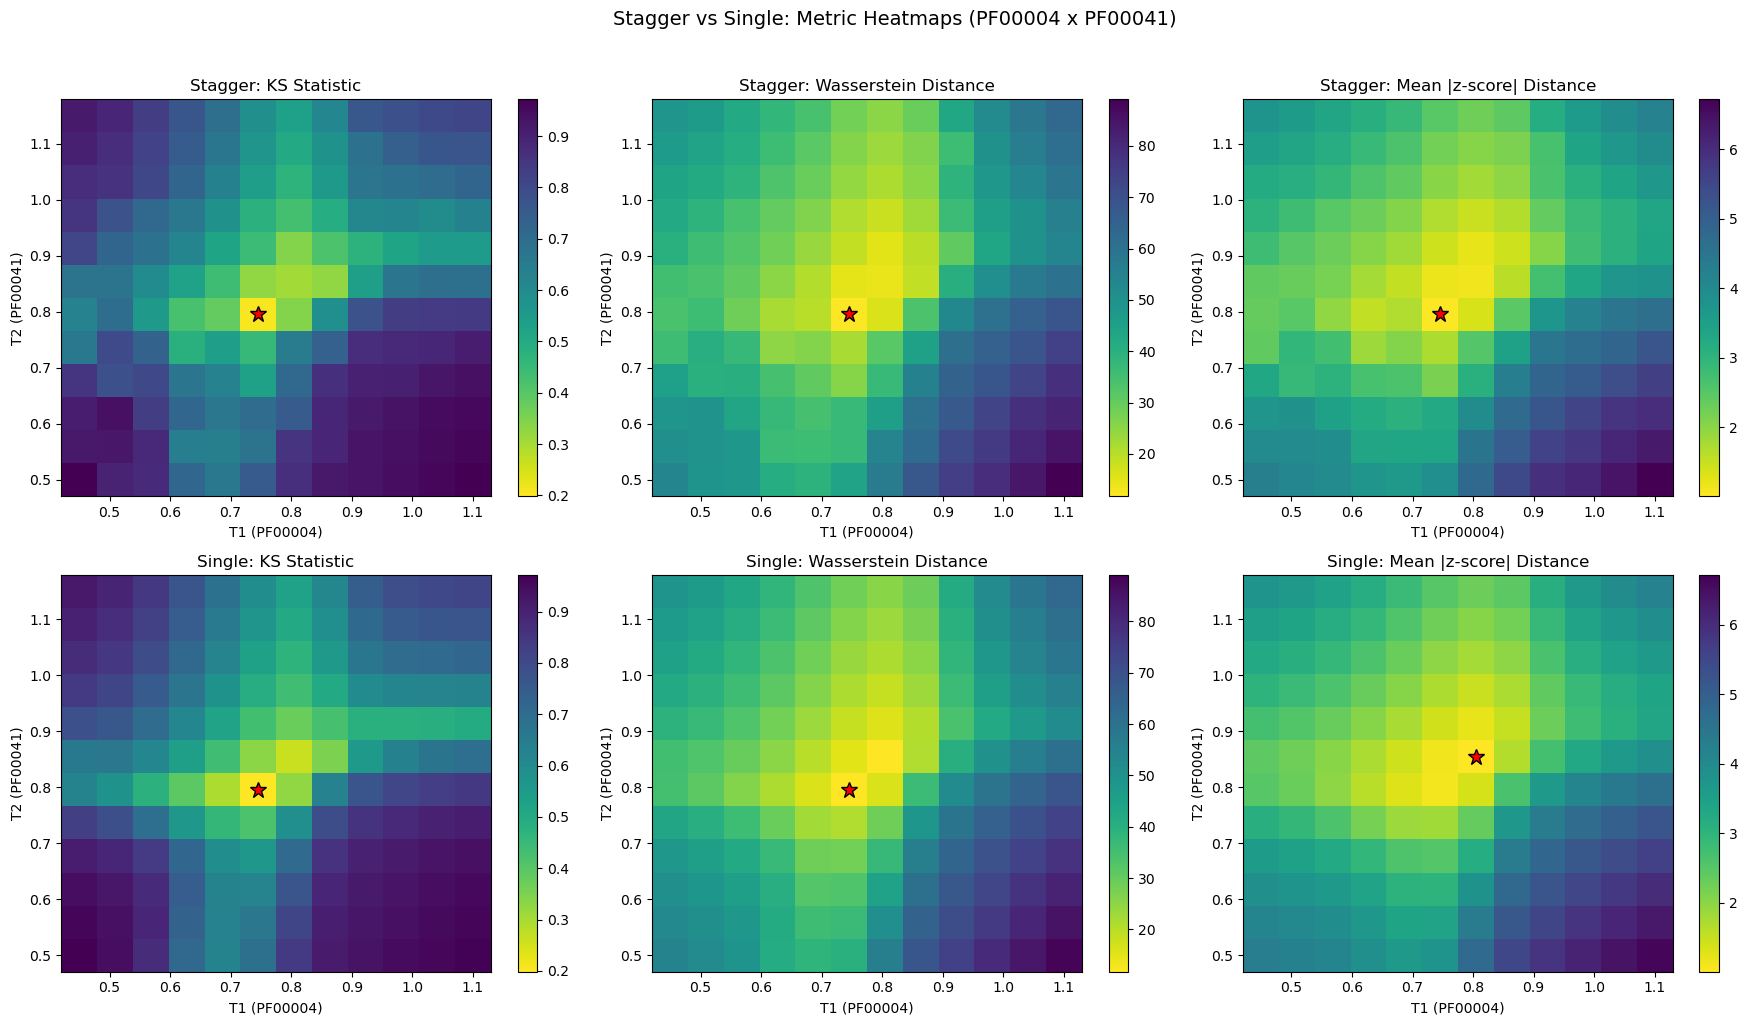

In [10]:
# === Cell 8: Side-by-Side Heatmaps (3 metrics x 2 approaches) ===

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

grids = [
    (ks_stag_mean, ks_sing_mean, "KS Statistic"),
    (wass_stag_mean, wass_sing_mean, "Wasserstein Distance"),
    (z_stag_mean, z_sing_mean, "Mean |z-score| Distance"),
]

for col, (stag_grid, sing_grid, title) in enumerate(grids):
    # Use shared colorbar range
    vmin = min(np.nanmin(stag_grid), np.nanmin(sing_grid))
    vmax = max(np.nanmax(stag_grid), np.nanmax(sing_grid))

    for row, (grid, label) in enumerate([(stag_grid, "Stagger"), (sing_grid, "Single")]):
        ax = axes[row, col]
        pcm = ax.pcolormesh(T1_fine, T2_fine, grid, cmap="viridis_r",
                            shading="auto", vmin=vmin, vmax=vmax)
        bT2, bT1, bval, _, _ = find_best(grid, T1_fine, T2_fine)
        ax.plot(bT1, bT2, "r*", markersize=12, markeredgecolor="k")
        ax.set_title(f"{label}: {title}")
        ax.set_xlabel(f"T1 ({PF1})")
        ax.set_ylabel(f"T2 ({PF2})")
        fig.colorbar(pcm, ax=ax)

fig.suptitle(f"Stagger vs Single: Metric Heatmaps ({PF1} x {PF2})", fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig("stagger_vs_single_heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()

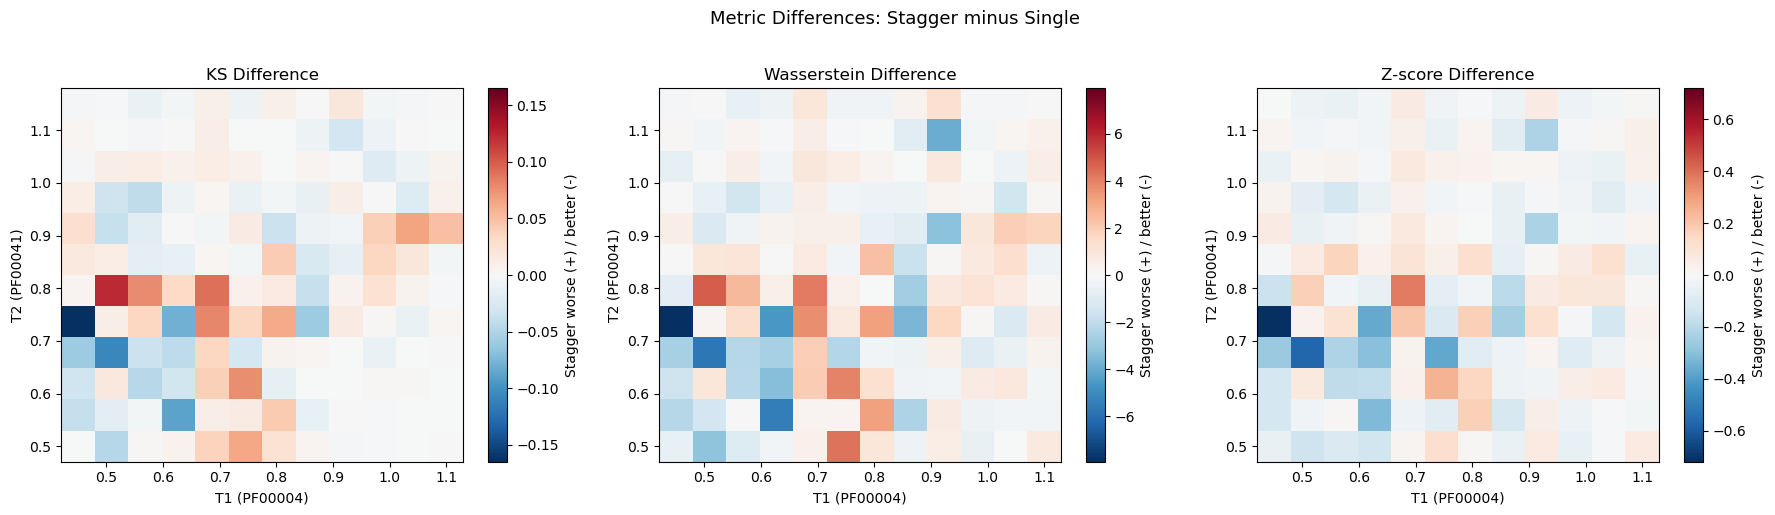

  KS: Stagger wins at 50.0% of grid, Single wins at 50.0%
  Wasserstein: Stagger wins at 48.6% of grid, Single wins at 51.4%
  Z-score: Stagger wins at 57.6% of grid, Single wins at 42.4%


In [11]:
# === Cell 9: Difference Heatmaps (Stagger - Single) ===
# Negative = stagger is better, Positive = single is better

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

diffs = [
    (ks_stag_mean - ks_sing_mean, "KS Difference"),
    (wass_stag_mean - wass_sing_mean, "Wasserstein Difference"),
    (z_stag_mean - z_sing_mean, "Z-score Difference"),
]

for ax, (diff_grid, title) in zip(axes, diffs):
    vmax = np.max(np.abs(diff_grid))
    pcm = ax.pcolormesh(T1_fine, T2_fine, diff_grid,
                        cmap="RdBu_r", shading="auto",
                        vmin=-vmax, vmax=vmax)
    ax.set_xlabel(f"T1 ({PF1})")
    ax.set_ylabel(f"T2 ({PF2})")
    ax.set_title(title)
    fig.colorbar(pcm, ax=ax, label="Stagger worse (+) / better (-)")

fig.suptitle("Metric Differences: Stagger minus Single",
             fontsize=13, y=1.02)
fig.tight_layout()
fig.savefig("stagger_vs_single_diffs.png", dpi=150, bbox_inches="tight")
plt.show()

# Print fraction of grid where each approach wins
for diff_grid, name in [(ks_stag_mean - ks_sing_mean, "KS"),
                         (wass_stag_mean - wass_sing_mean, "Wasserstein"),
                         (z_stag_mean - z_sing_mean, "Z-score")]:
    stagger_wins = np.sum(diff_grid < 0) / diff_grid.size * 100
    single_wins = np.sum(diff_grid > 0) / diff_grid.size * 100
    print(f"  {name}: Stagger wins at {stagger_wins:.1f}% of grid, "
          f"Single wins at {single_wins:.1f}%")

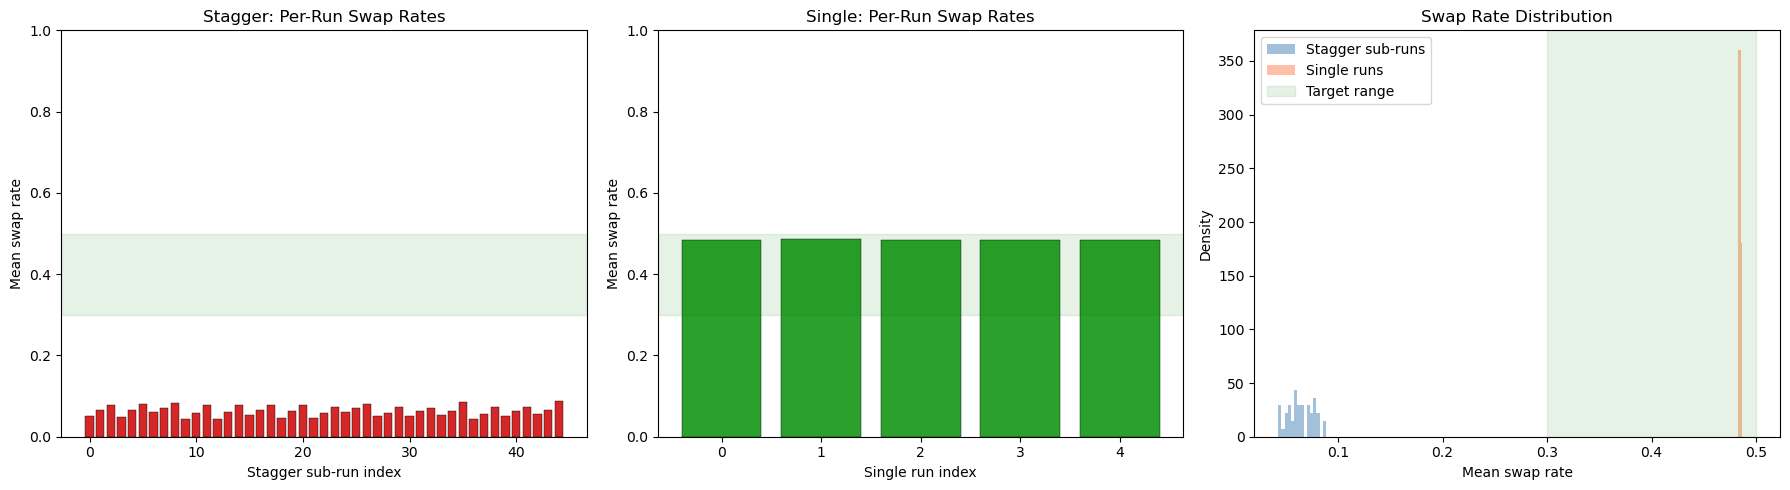

In [12]:
# === Cell 10: Swap Rate Comparison ===

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Stagger per-run swap rates
ax = axes[0]
swap_stag = [d['mean_swap'] for d in diag_stagger]
colors = ['#2ca02c' if 0.3 <= s <= 0.5 else '#d62728' if s < 0.2 or s > 0.7
          else '#ff7f0e' for s in swap_stag]
ax.bar(range(len(swap_stag)), swap_stag, color=colors, edgecolor='k', linewidth=0.3)
ax.axhspan(0.3, 0.5, alpha=0.1, color='green')
ax.set_xlabel('Stagger sub-run index')
ax.set_ylabel('Mean swap rate')
ax.set_title('Stagger: Per-Run Swap Rates')
ax.set_ylim(0, 1)

# Panel 2: Single per-run swap rates
ax = axes[1]
swap_sing = [d['mean_swap'] for d in diag_single]
colors = ['#2ca02c' if 0.3 <= s <= 0.5 else '#d62728' if s < 0.2 or s > 0.7
          else '#ff7f0e' for s in swap_sing]
ax.bar(range(len(swap_sing)), swap_sing, color=colors, edgecolor='k', linewidth=0.3)
ax.axhspan(0.3, 0.5, alpha=0.1, color='green')
ax.set_xlabel('Single run index')
ax.set_ylabel('Mean swap rate')
ax.set_title('Single: Per-Run Swap Rates')
ax.set_ylim(0, 1)

# Panel 3: Histogram comparison
ax = axes[2]
ax.hist(swap_stag, bins=15, alpha=0.5, color='steelblue', label='Stagger sub-runs', density=True)
ax.hist(swap_sing, bins=max(3, len(swap_sing)//2), alpha=0.5, color='coral',
        label='Single runs', density=True)
ax.axvspan(0.3, 0.5, alpha=0.1, color='green', label='Target range')
ax.set_xlabel('Mean swap rate')
ax.set_ylabel('Density')
ax.set_title('Swap Rate Distribution')
ax.legend()

fig.tight_layout()
fig.savefig("stagger_vs_single_swaps.png", dpi=150, bbox_inches="tight")
plt.show()

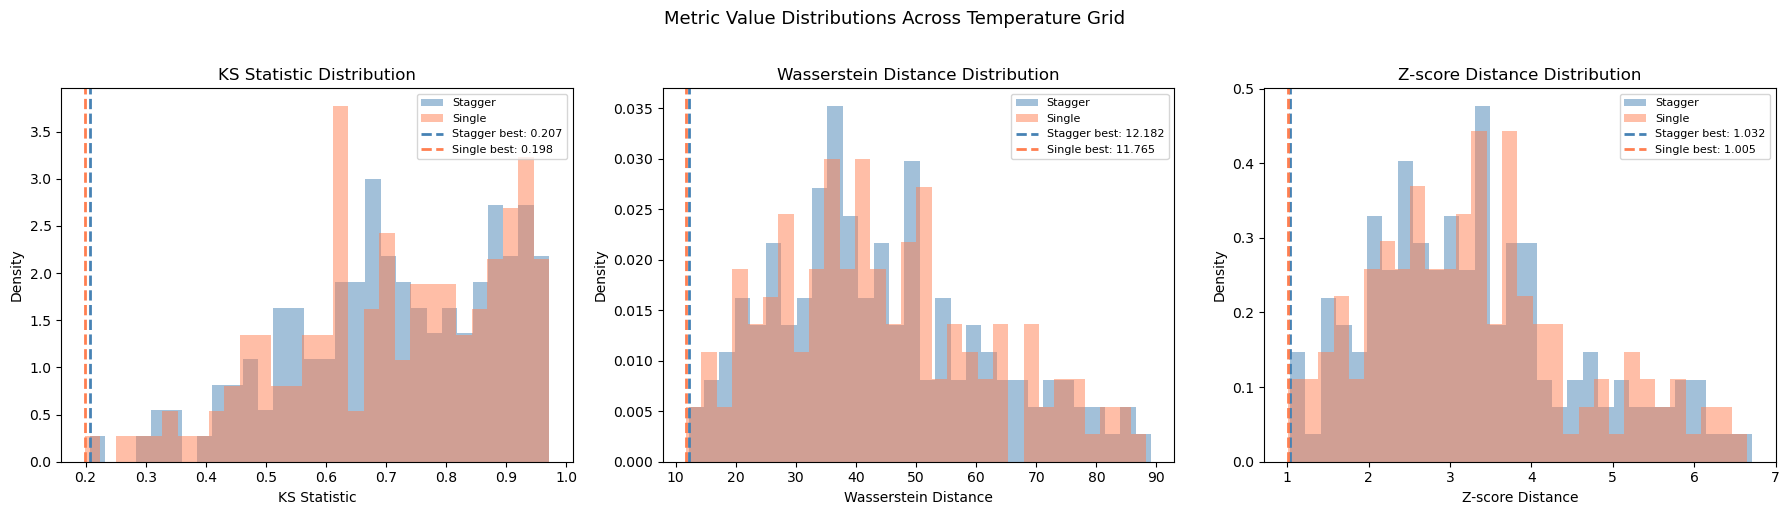

In [13]:
# === Cell 11: Metric Distributions Across Grid Points ===

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, stag_mean, sing_mean, title in zip(
    axes,
    [ks_stag_mean, wass_stag_mean, z_stag_mean],
    [ks_sing_mean, wass_sing_mean, z_sing_mean],
    ["KS Statistic", "Wasserstein Distance", "Z-score Distance"],
):
    ax.hist(stag_mean.ravel(), bins=30, alpha=0.5, color='steelblue',
            label='Stagger', density=True)
    ax.hist(sing_mean.ravel(), bins=30, alpha=0.5, color='coral',
            label='Single', density=True)
    ax.axvline(np.min(stag_mean), color='steelblue', linestyle='--', linewidth=2,
               label=f'Stagger best: {np.min(stag_mean):.3f}')
    ax.axvline(np.min(sing_mean), color='coral', linestyle='--', linewidth=2,
               label=f'Single best: {np.min(sing_mean):.3f}')
    ax.set_xlabel(title)
    ax.set_ylabel('Density')
    ax.set_title(f'{title} Distribution')
    ax.legend(fontsize=8)

fig.suptitle("Metric Value Distributions Across Temperature Grid", fontsize=13, y=1.02)
fig.tight_layout()
fig.savefig("stagger_vs_single_metric_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

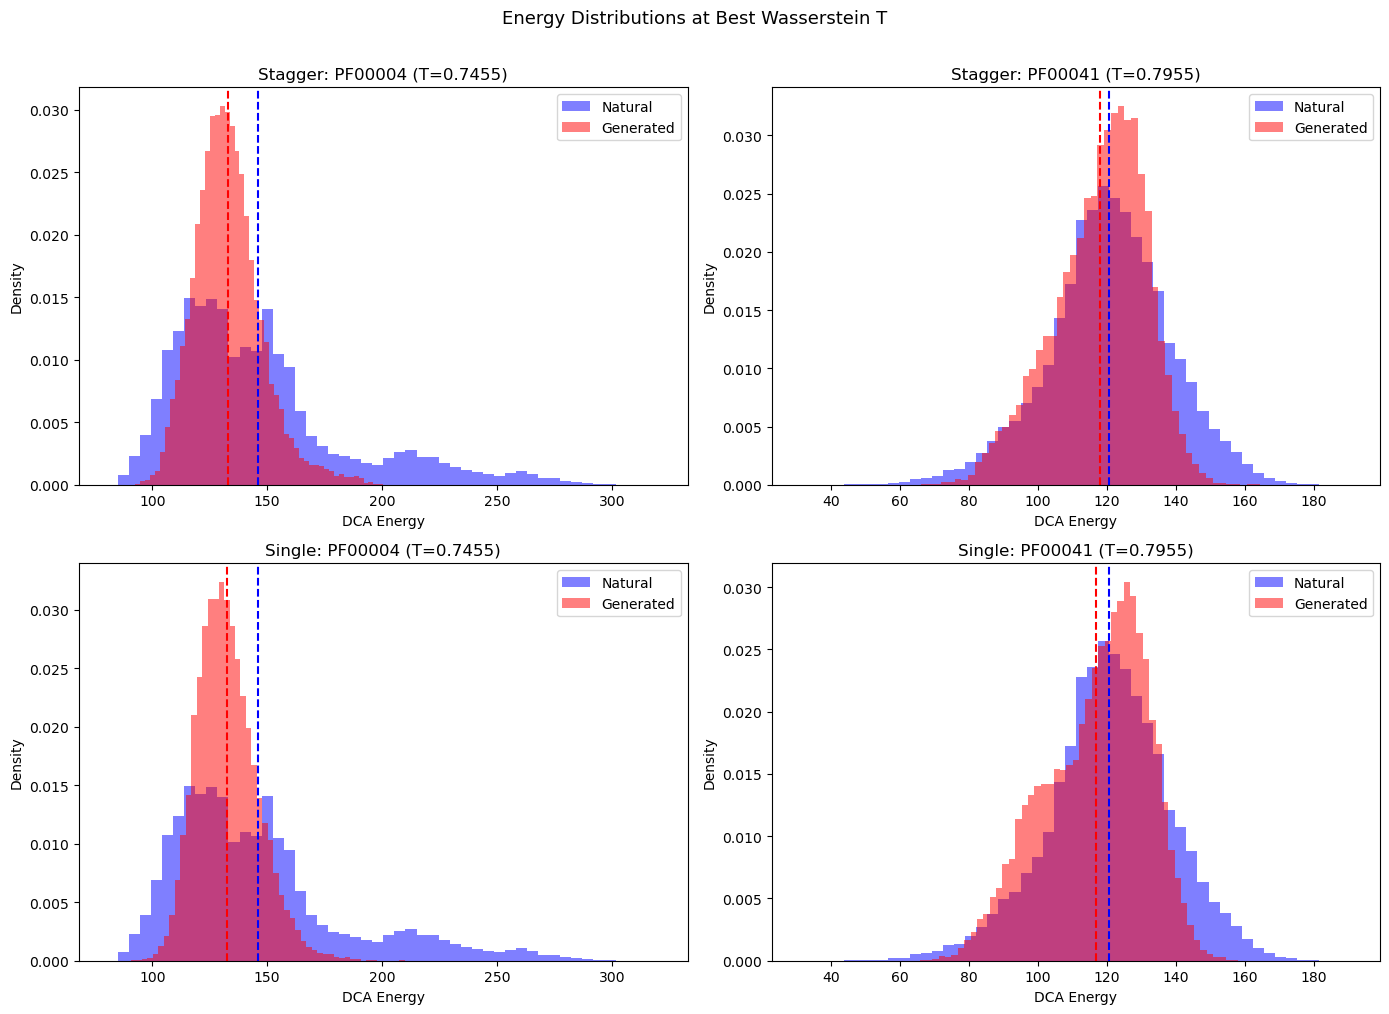

In [14]:
# === Cell 12: Energy Histograms at Best Wasserstein T ===

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for row, (label, wass_m, E1_arr, E2_arr) in enumerate([
    ("Stagger", wass_stag_mean, E1_stagger, E2_stagger),
    ("Single",  wass_sing_mean,  E1_single,  E2_single),
]):
    bT2, bT1, bval, wi, wj = find_best(wass_m, T1_fine, T2_fine)

    # Concatenate across repeats
    E1_best = np.concatenate([E1_arr[r, wi, wj] for r in range(N_REPEATS)])
    E2_best = np.concatenate([E2_arr[r, wi, wj] for r in range(N_REPEATS)])

    for col, (nat_e, gen_e, pf, T_val) in enumerate([
        (nat_energies_1, E1_best, PF1, bT1),
        (nat_energies_2, E2_best, PF2, bT2),
    ]):
        ax = axes[row, col]
        ax.hist(nat_e, bins=50, density=True, alpha=0.5, color="blue", label="Natural")
        ax.hist(gen_e, bins=50, density=True, alpha=0.5, color="red", label="Generated")
        ax.axvline(np.mean(nat_e), color="blue", linestyle="--", linewidth=1.5)
        ax.axvline(np.mean(gen_e), color="red", linestyle="--", linewidth=1.5)
        ax.set_xlabel("DCA Energy")
        ax.set_ylabel("Density")
        ax.set_title(f"{label}: {pf} (T={T_val:.4f})")
        ax.legend()

fig.suptitle("Energy Distributions at Best Wasserstein T", fontsize=13, y=1.01)
fig.tight_layout()
fig.savefig("stagger_vs_single_energy_hist.png", dpi=150, bbox_inches="tight")
plt.show()

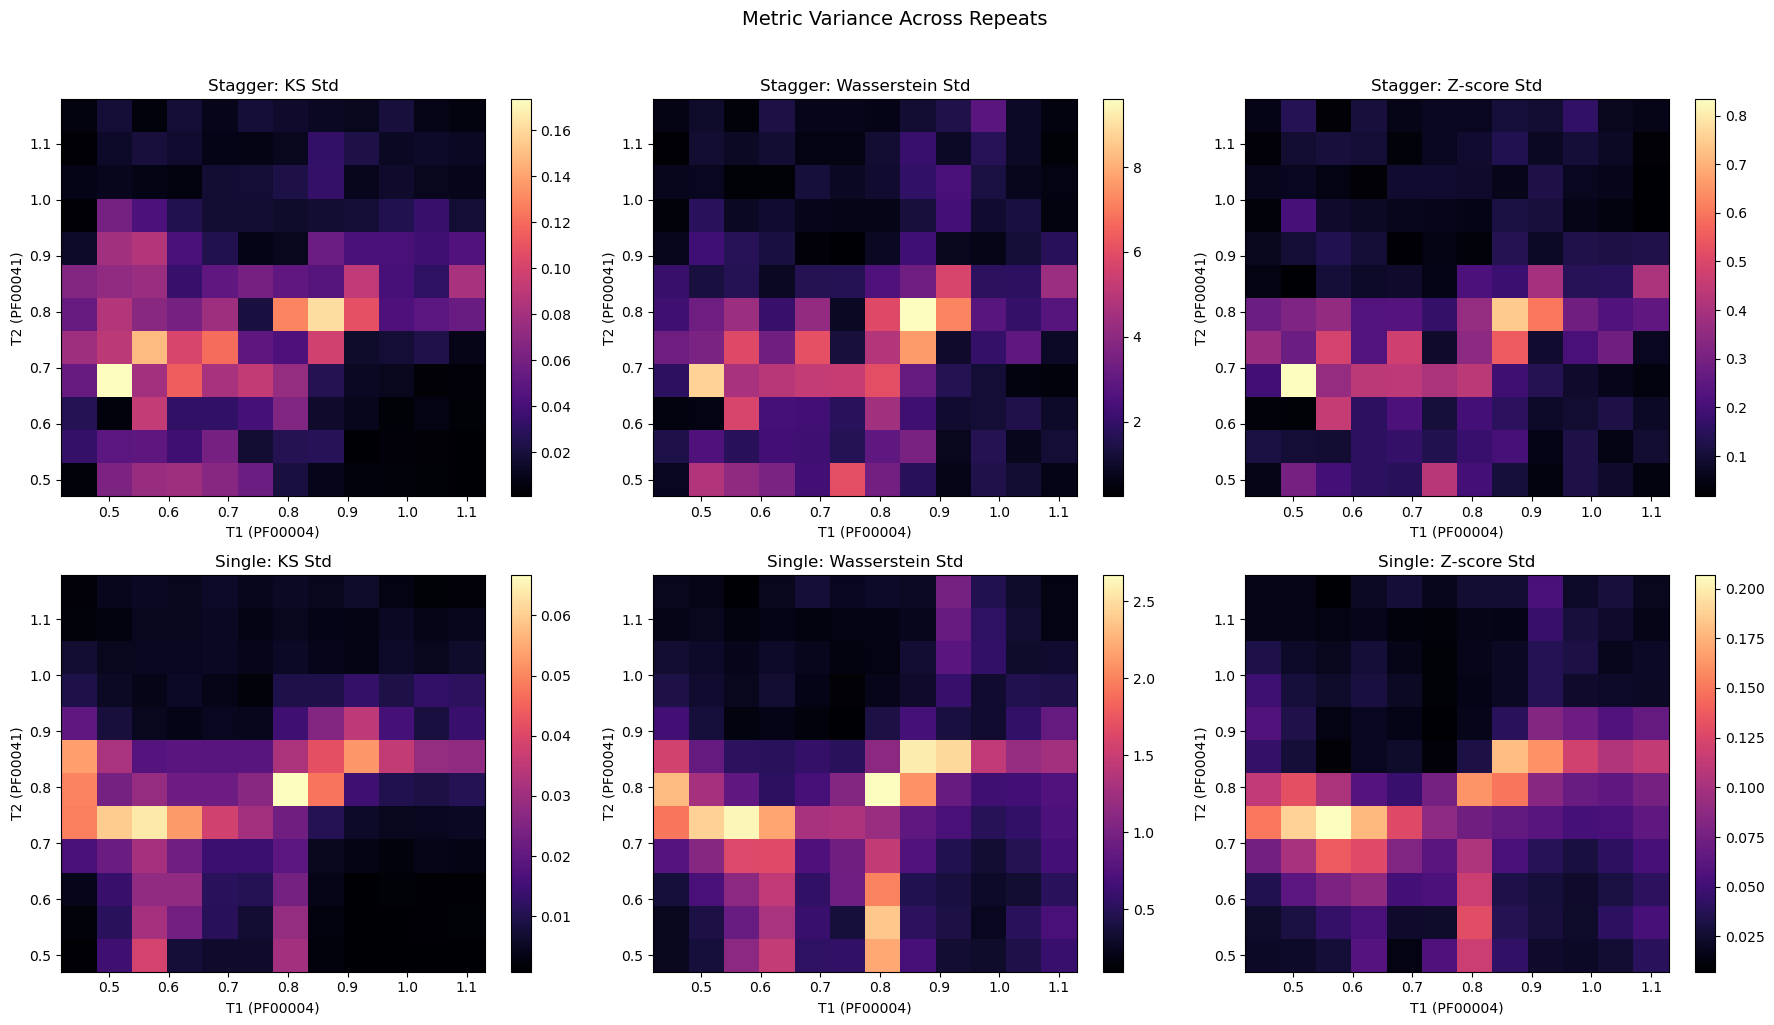

Mean std across full grid:
  KS:    Stagger=0.0377, Single=0.0137
  Wass:  Stagger=2.11, Single=0.71
  Z:     Stagger=0.1578, Single=0.0514


In [15]:
# === Cell 13: Variance Comparison (Repeatability) ===

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for row, (label, ks_s, wass_s, z_s) in enumerate([
    ("Stagger", ks_stag_std, wass_stag_std, z_stag_std),
    ("Single",  ks_sing_std,  wass_sing_std,  z_sing_std),
]):
    for col, (grid, title) in enumerate([
        (ks_s, "KS Std"),
        (wass_s, "Wasserstein Std"),
        (z_s, "Z-score Std"),
    ]):
        ax = axes[row, col]
        pcm = ax.pcolormesh(T1_fine, T2_fine, grid, cmap="magma", shading="auto")
        ax.set_xlabel(f"T1 ({PF1})")
        ax.set_ylabel(f"T2 ({PF2})")
        ax.set_title(f"{label}: {title}")
        fig.colorbar(pcm, ax=ax)

fig.suptitle("Metric Variance Across Repeats", fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig("stagger_vs_single_variance.png", dpi=150, bbox_inches="tight")
plt.show()

print("Mean std across full grid:")
print(f"  KS:    Stagger={np.mean(ks_stag_std):.4f}, Single={np.mean(ks_sing_std):.4f}")
print(f"  Wass:  Stagger={np.mean(wass_stag_std):.2f}, Single={np.mean(wass_sing_std):.2f}")
print(f"  Z:     Stagger={np.mean(z_stag_std):.4f}, Single={np.mean(z_sing_std):.4f}")

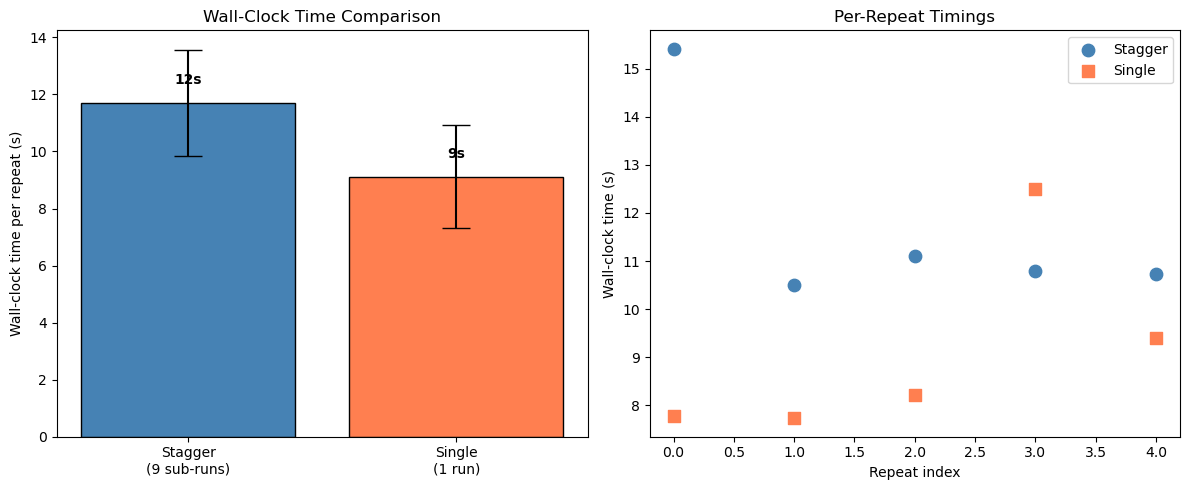

Time ratio (Single / Stagger): 0.78x


In [16]:
# === Cell 14: Wall-Clock Time Comparison ===

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
ax = axes[0]
means = [np.mean(time_stagger), np.mean(time_single)]
stds = [np.std(time_stagger), np.std(time_single)]
bars = ax.bar(['Stagger\n(9 sub-runs)', 'Single\n(1 run)'],
              means, yerr=stds, capsize=10,
              color=['steelblue', 'coral'], edgecolor='k')
ax.set_ylabel('Wall-clock time per repeat (s)')
ax.set_title('Wall-Clock Time Comparison')
for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + stds[0]*0.3,
            f'{m:.0f}s', ha='center', va='bottom', fontweight='bold')

# Per-repeat scatter
ax = axes[1]
ax.scatter(range(N_REPEATS), time_stagger, marker='o', s=80,
           color='steelblue', label='Stagger', zorder=3)
ax.scatter(range(N_REPEATS), time_single, marker='s', s=80,
           color='coral', label='Single', zorder=3)
ax.set_xlabel('Repeat index')
ax.set_ylabel('Wall-clock time (s)')
ax.set_title('Per-Repeat Timings')
ax.legend()

fig.tight_layout()
fig.savefig("stagger_vs_single_timing.png", dpi=150, bbox_inches="tight")
plt.show()

speedup = np.mean(time_single) / np.mean(time_stagger)
print(f"Time ratio (Single / Stagger): {speedup:.2f}x")

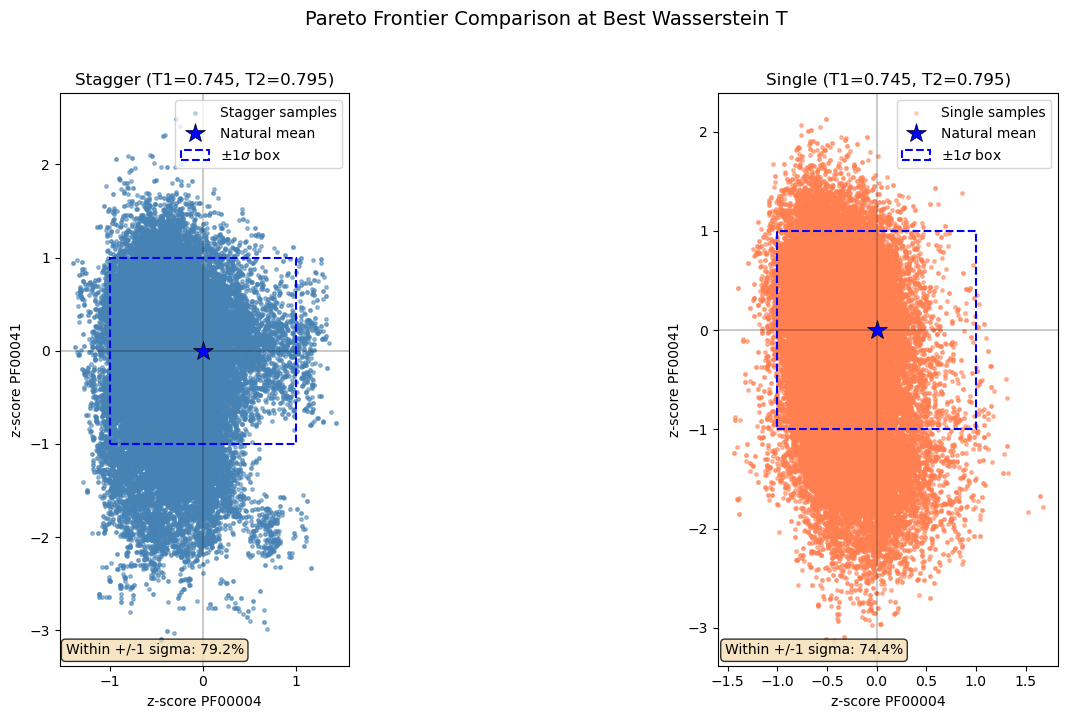

In [17]:
# === Cell 15: Pareto Frontier Comparison ===

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax_idx, (label, wass_m, E1_arr, E2_arr, color) in enumerate([
    ("Stagger", wass_stag_mean, E1_stagger, E2_stagger, "steelblue"),
    ("Single",  wass_sing_mean,  E1_single,  E2_single,  "coral"),
]):
    bT2, bT1, bval, wi, wj = find_best(wass_m, T1_fine, T2_fine)
    E1_best = np.concatenate([E1_arr[r, wi, wj] for r in range(N_REPEATS)])
    E2_best = np.concatenate([E2_arr[r, wi, wj] for r in range(N_REPEATS)])

    z1 = (E1_best - mean_1) / std_1
    z2 = (E2_best - mean_2) / std_2

    ax = axes[ax_idx]
    ax.scatter(z1, z2, s=6, alpha=0.3, c=color, label=f"{label} samples")
    ax.plot(0, 0, "b*", markersize=15, markeredgecolor="k", markeredgewidth=0.5,
            zorder=5, label="Natural mean")
    rect = plt.Rectangle((-1, -1), 2, 2, fill=False, edgecolor="blue",
                          linestyle="--", linewidth=1.5, label=r"$\pm 1\sigma$ box")
    ax.add_patch(rect)
    ax.set_xlabel(f"z-score {PF1}")
    ax.set_ylabel(f"z-score {PF2}")
    ax.set_title(f"{label} (T1={bT1:.3f}, T2={bT2:.3f})")
    ax.legend(loc="upper right")
    ax.set_aspect("equal")
    ax.axhline(0, color="k", linewidth=0.3)
    ax.axvline(0, color="k", linewidth=0.3)

    within = np.sum((np.abs(z1) <= 1) & (np.abs(z2) <= 1)) / len(z1) * 100
    ax.text(0.02, 0.02, f"Within +/-1 sigma: {within:.1f}%",
            transform=ax.transAxes, fontsize=10,
            bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8))

fig.suptitle("Pareto Frontier Comparison at Best Wasserstein T", fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig("stagger_vs_single_pareto.png", dpi=150, bbox_inches="tight")
plt.show()

## Summary

| Aspect | Stagger (A) | Single (B) |
|--------|-------------|------------|
| Total MC steps | Same | Same |
| Replicas per run | 100 (10x10) | 900 (30x30) |
| Swap neighbor spacing | 3x wider | 1x (fine) |
| Expected swap rate | Lower (wider gaps) | Higher (fine gaps) |
| Independence across sub-runs | Yes (9 independent runs) | No (one chain) |
| Memory footprint per run | Smaller | Larger (~9x) |

### Key findings:
- Fill in after running the notebook